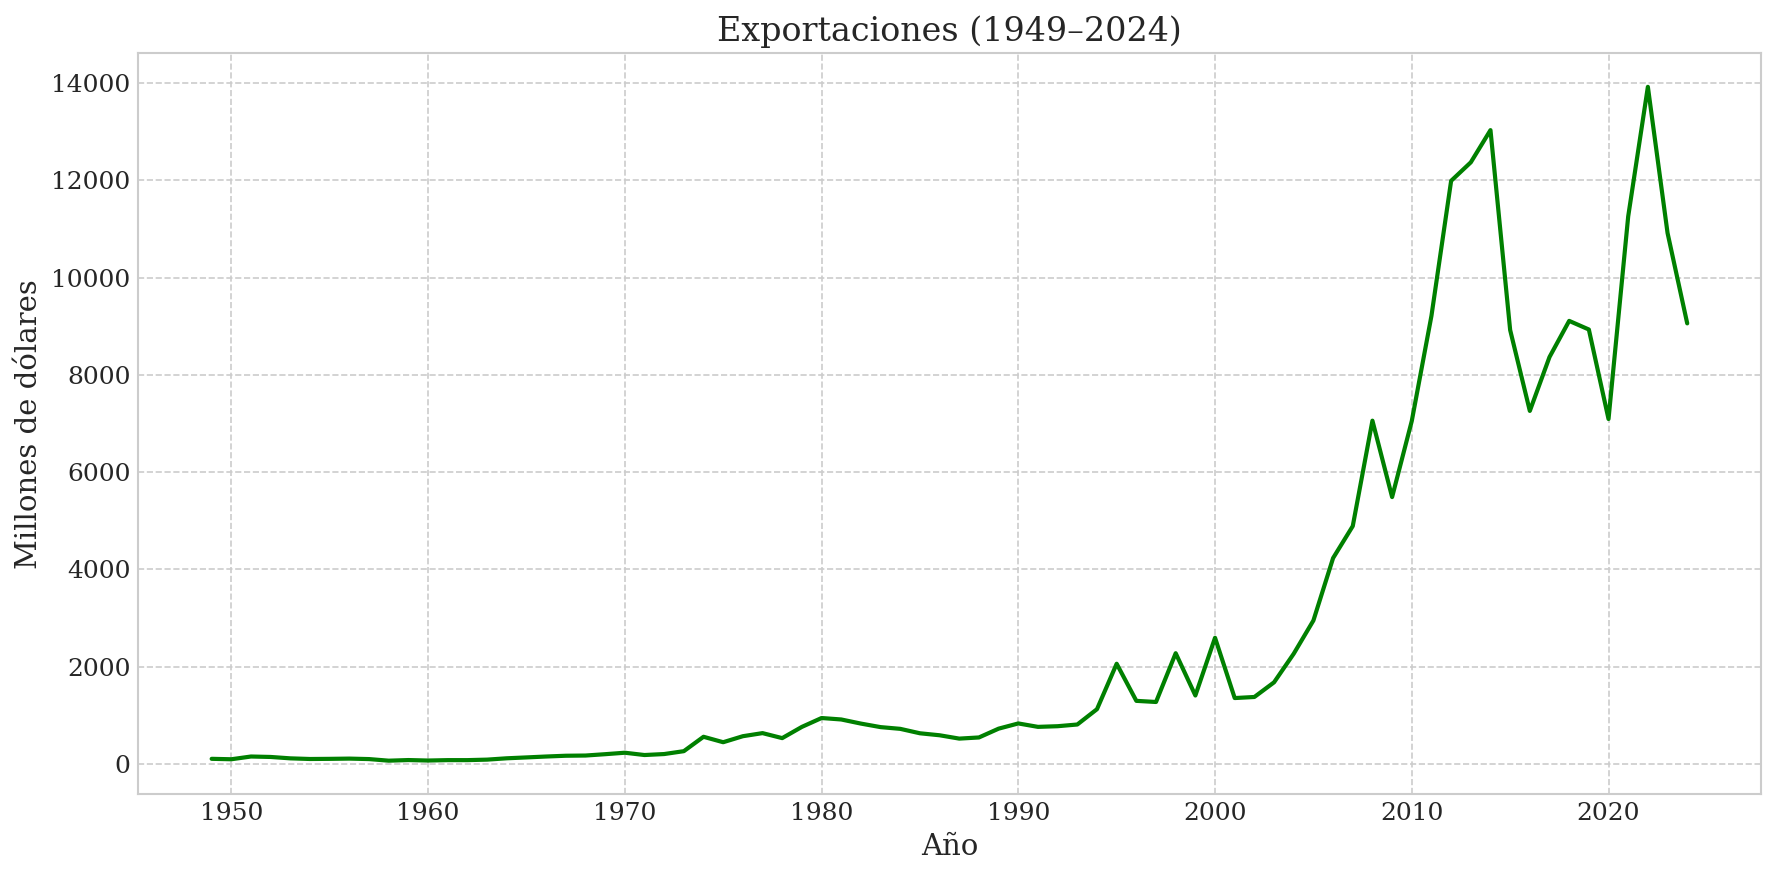

In [8]:
import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from func_auxiliares.graficos_utils import set_style  # estilo corporativo
from func_auxiliares.config import DB_PATH
import numpy as np
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import het_arch
from scipy.stats import levene

# 1) Configuración
output_dir = "../../../assets/tesis/serie_completa/balanza_comercial"
os.makedirs(output_dir, exist_ok=True)
set_style()

# 2) Carga de datos (solo exportaciones)
with sqlite3.connect(str(DB_PATH)) as conn:
    df = (
        pd.read_sql(
            "SELECT año, exportaciones FROM balanza_comercial",
            conn,
            index_col="año"
        ).sort_index()
    )

# 3) Gráfica simple (sin anotaciones, sin cuadros/leyenda)
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df.index, df["exportaciones"], linewidth=2, color="green")

# Etiquetas básicas (si las quieres totalmente limpias, comenta estas 3 líneas)
ax.set_title(f"Exportaciones ({int(df.index.min())}–{int(df.index.max())})")
ax.set_xlabel("Año")
ax.set_ylabel("Millones de dólares")

# No agregamos leyenda ni objetos adicionales
plt.tight_layout()
plt.show()


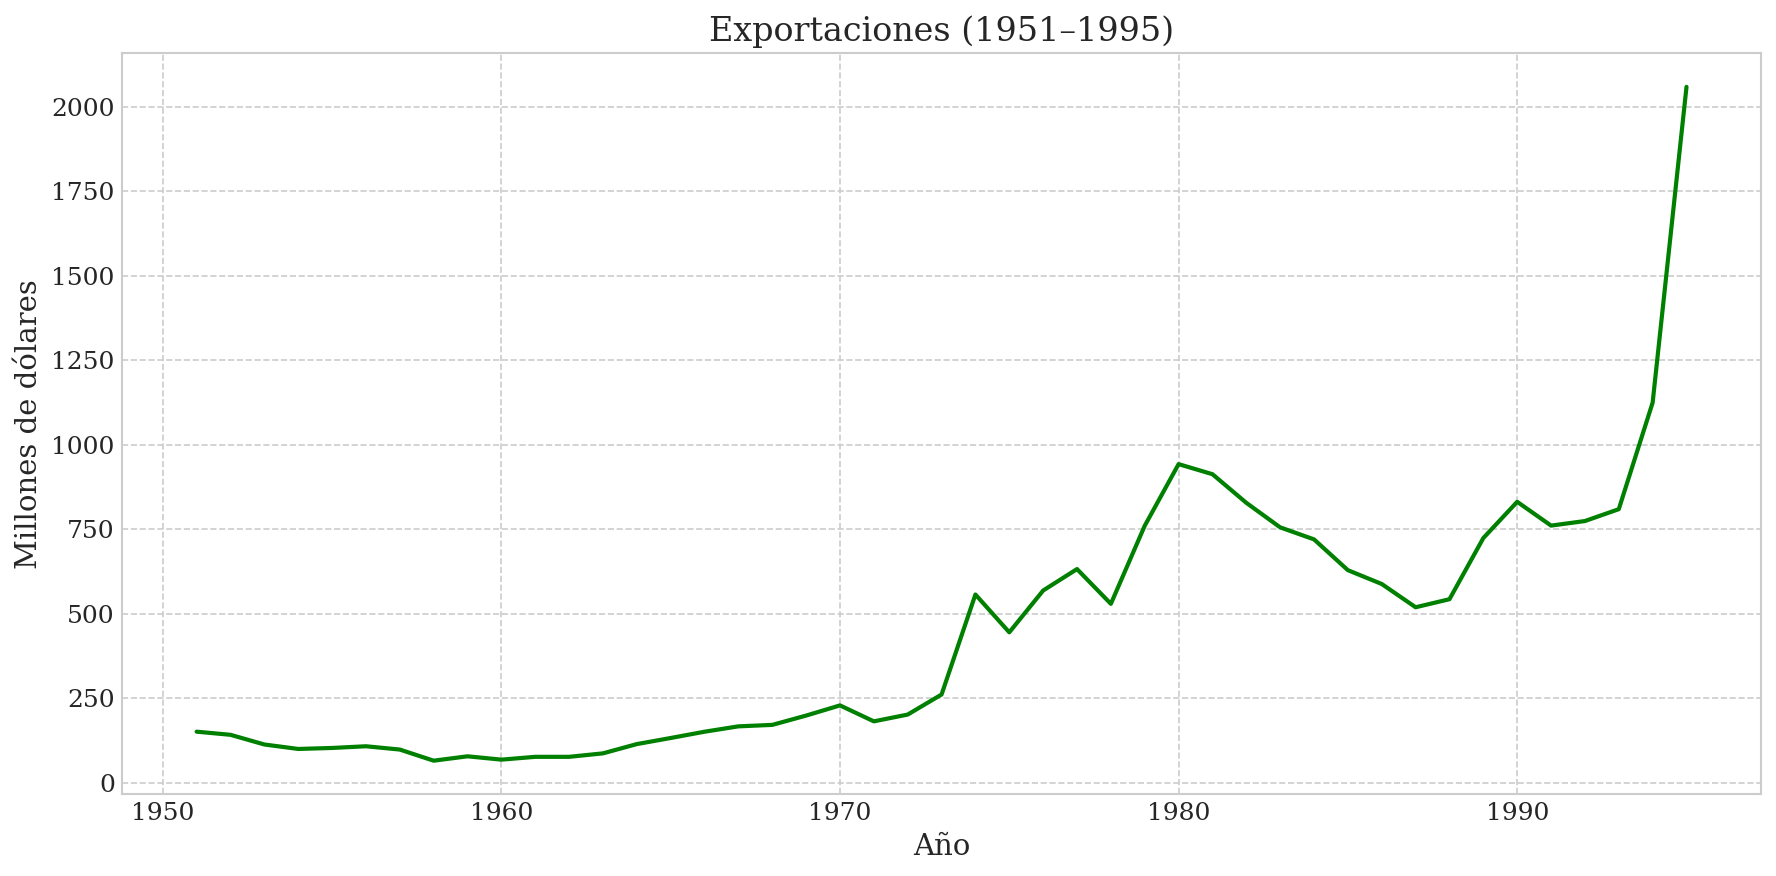

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
df_subset = df.loc[1951:1995]
ax.plot(df_subset.index, df_subset["exportaciones"], linewidth=2, color="green")

ax.set_title(f"Exportaciones ({df_subset.index.min()}–{df_subset.index.max()})")
ax.set_xlabel("Año")
ax.set_ylabel("Millones de dólares")

plt.tight_layout()
plt.show()


### Exportaciones (serie anual): componentes observados

- **Estacionalidad:** No aplicable. Frecuencia anual ⇒ s = 1, no existe patrón intra-anual repetitivo que remover.
- **Ciclo (5–7 años):** Oscilaciones de mediano plazo sin período fijo (p.ej., “ciclo ascendente por precios”). Se sugieren picos en ACF a rezagos 5–7 o en el espectro.
- **Tendencia:** Cambio de largo plazo en el nivel medio, **no lineal** y con posibles quiebres estructurales. Estimable con suavizadores (LOESS), modelos por tramos, filtro HP, media movil o escala log.
- **Irregular (ruido):** Variación residual tras remover tendencia/ciclo; se modela como ruido blanco o procesos ARMA dentro de ARIMA.

In [10]:
# 1) Primera diferencia (ΔX_t = X_t - X_{t-1})
df_diff = df.diff().dropna()                # resultado en nuevo DataFrame
# o, si quieres sobrescribir la variable original:
# df = df.diff().dropna()

# 2) (Opcional) renombrar la columna para mayor claridad
df_diff = df_diff.rename(columns={"exportaciones": "exportaciones_diff"})

# 3) Mostrar un resumen rápido
# Mostrar todo el DataFrame sin truncar filas ni columnas
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(df_diff)

,exportaciones_diff
año,
1950,-8.898
1951,56.518
1952,-9.287
1953,-28.640
1954,-13.210
1955,2.921
1956,5.063
1957,-9.770
1958,-32.931


In [11]:
# Serie diferenciada (ΔX_t)
x = df_diff["exportaciones_diff"].astype(float).dropna()

# 1) Media estable (sin raíz unitaria)
adf_stat, adf_p, *_ = adfuller(x, autolag="AIC")              # H0: no estacionaria (raíz unitaria)
kpss_stat, kpss_p, *_ = kpss(x, regression="c", nlags="auto") # H0: estacionaria alrededor de constante

# 2) Varianza estable (sin heterocedasticidad condicional)
arch_lm, arch_p, _, _ = het_arch(x, maxlag=5)                 # H0: varianza constante (sin ARCH)

# 3) Varianza similar a lo largo del tiempo (chequeo en bloques)
blocks = np.array_split(x.values, 3)                          # divide en 3 tramos del tiempo
lev_stat, lev_p = levene(*blocks, center="median")            # H0: varianzas iguales entre bloques

print(f"ADF p-value:   {adf_p:.4f}  (H0: raíz unitaria)")
print(f"KPSS p-value:  {kpss_p:.4f} (H0: estacionaria en nivel)")
print(f"ARCH-LM p-val: {arch_p:.4f} (H0: varianza constante/sin ARCH)")
print(f"Levene p-val:  {lev_p:.4f} (H0: varianzas iguales entre tramos)")

# Regla práctica de decisión
if (adf_p < 0.05) and (kpss_p > 0.05) and (arch_p > 0.05) and (lev_p > 0.05):
    print("Conclusión: consistente con estacionariedad (media y varianza estables).")
else:
    print("Conclusión: posible no-estacionariedad; revisar log/Box-Cox, d adicional o rupturas.")

ADF p-value:   0.0000  (H0: raíz unitaria)
KPSS p-value:  0.1000 (H0: estacionaria en nivel)
ARCH-LM p-val: 0.0095 (H0: varianza constante/sin ARCH)
Levene p-val:  0.0000 (H0: varianzas iguales entre tramos)
Conclusión: posible no-estacionariedad; revisar log/Box-Cox, d adicional o rupturas.


/tmp/ipykernel_15381/437213627.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(x, regression="c", nlags="auto") # H0: estacionaria alrededor de constante
/tmp/ipykernel_15381/437213627.py:9: FutureWarning: the 'maxlag' keyword is deprecated, use 'nlags' instead.
  arch_lm, arch_p, _, _ = het_arch(x, maxlag=5)                 # H0: varianza constante (sin ARCH)


## 1) Diferenciación (qué y por qué)
- **Qué hicimos:** calculaste la **primera diferencia** de la serie de exportaciones:  
  \(\Delta X_t = X_t - X_{t-1}\).  
- **Objetivo:** eliminar la **tendencia** (cambiar la serie a variaciones año-a-año) para estabilizar la **media** y dejar una serie apta para modelado ARMA/ARIMA.  
- **Efecto práctico:** la diferencia reduce o elimina cambios de nivel de largo plazo; **no** siempre estabiliza la varianza (para eso usamos transformaciones como log o Box–Cox).

---

## 2) Pruebas realizadas (qué test, H₀ y qué busca cada uno)
- **ADF (Augmented Dickey-Fuller)**  
  - **H₀:** la serie tiene raíz unitaria (no estacionaria en la media).  
  - **Interpretación práctica:** p-value pequeño ⇒ rechazamos H₀ ⇒ *la media no tiene una raíz unitaria* (señal de estacionariedad en la media).
  - **Resultado:** `ADF p-value: 0.0000` → **rechazo H₀** → media estable.

- **KPSS**  
  - **H₀:** la serie es estacionaria alrededor de una constante.  
  - **Interpretación práctica:** p-value grande ⇒ no rechazamos H₀ ⇒ *la serie es compatible con estacionariedad en el nivel*.  
  - **Resultado:** `KPSS p-value: 0.1000` → **no rechazo** → acorde con ADF (ambos indican media estable).

- **ARCH-LM (prueba de heterocedasticidad condicional)**  
  - **H₀:** no hay efecto ARCH (varianza condicional constante).  
  - **Interpretación práctica:** p-value pequeño ⇒ evidencia de volatilidad dependiente del tiempo (clusters de varianza).  
  - **Resultado:** `ARCH-LM p-val: 0.0095` → **rechazo H₀** → indica **heterocedasticidad condicional** (varianza dependiente del pasado).

- **Levene (comparación de varianzas por tramos)**  
  - **H₀:** varianzas iguales entre los tramos temporales (homocedasticidad entre bloques).  
  - **Interpretación práctica:** p-value pequeño ⇒ varianzas diferentes entre tramos (rupturas o cambios de régimen en la varianza).  
  - **Resultado:** `Levene p-val: 0.0000` → **rechazo H₀** → varianzas distintas por periodos.

---

## 3) Resultado e interpretación conjunta
- **Media:** ambas pruebas (ADF muy pequeño y KPSS no significativo) coinciden → **la media de la serie diferenciada está estacionaria**.  
- **Varianza:** las pruebas contradicen la constancia de varianza: **hay evidencia clara de varianza no constante** (ARCH-LM y Levene significativos).  
- **Conclusión lógica:** aunque la media está estabilizada por la diferenciación, **la varianza aún no es constante**, por lo que NO se cumple plenamente la definición práctica de estacionariedad (media *y* varianza estables). Por eso tu check final devolvió: *“posible no-estacionariedad; revisar log/Box-Cox, d adicional o rupturas.”*

**Resumen en 1 línea:** la **diferenciación** resolvió la media, pero las pruebas muestran **varianza no constante** en la serie diferenciada — por eso debes aplicar una transformación de varianza (log/Box–Cox) o modelar la volatilidad antes de considerar la serie completamente apta para un ARIMA estándar.
::contentReference[oaicite:0]{index=0}

In [12]:
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.diagnostic import het_arch
from scipy.stats import levene

# ts en nivel (no diferenciada) desde tu df original
ts = df["exportaciones"].astype(float).dropna()

# A) Log-diff (si todos > 0)
if (ts > 0).all():
    x_1 = np.log(ts).diff().dropna()          # ≈ tasa de crecimiento
else:
    # B) Box-Cox en nivel (con shift si hay ≤0), luego diff
    shift = 1 - ts.min() if (ts <= 0).any() else 0.0
    bc, lam = stats.boxcox(ts + shift)
    x_1 = pd.Series(bc, index=ts.index).diff().dropna()

# Re-test varianza (heterocedasticidad)
arch_p = het_arch(x_1, nlags=5)[1]            # H0: varianza constante
blocks = np.array_split(x_1.values, 3)
lev_p  = levene(*blocks, center="median")[1]# H0: varianzas iguales entre tramos
print(f"ARCH-LM p={arch_p:.4f} | Levene p={lev_p:.4f}")

# 1) Media estable (sin raíz unitaria)
adf_stat, adf_p, *_ = adfuller(x_1, autolag="AIC")              # H0: no estacionaria (raíz unitaria)
kpss_stat, kpss_p, *_ = kpss(x_1, regression="c", nlags="auto") # H0: estacionaria alrededor de constante

# 2) Varianza estable (sin heterocedasticidad condicional)
arch_lm, arch_p, _, _ = het_arch(x_1, maxlag=5)                 # H0: varianza constante (sin ARCH)

# 3) Varianza similar a lo largo del tiempo (chequeo en bloques)
blocks = np.array_split(x_1.values, 3)                          # divide en 3 tramos del tiempo
lev_stat, lev_p = levene(*blocks, center="median")            # H0: varianzas iguales entre bloques

print(f"ADF p-value:   {adf_p:.4f}  (H0: raíz unitaria)")
print(f"KPSS p-value:  {kpss_p:.4f} (H0: estacionaria en nivel)")
print(f"ARCH-LM p-val: {arch_p:.4f} (H0: varianza constante/sin ARCH)")
print(f"Levene p-val:  {lev_p:.4f} (H0: varianzas iguales entre tramos)")

# Regla práctica de decisión
if (adf_p < 0.05) and (kpss_p > 0.05) and (arch_p > 0.05) and (lev_p > 0.05):
    print("Conclusión: consistente con estacionariedad (media y varianza estables).")
else:
    print("Conclusión: posible no-estacionariedad; revisar log/Box-Cox, d adicional o rupturas.")


ARCH-LM p=0.0587 | Levene p=0.4774
ADF p-value:   0.0000  (H0: raíz unitaria)
KPSS p-value:  0.1000 (H0: estacionaria en nivel)
ARCH-LM p-val: 0.0587 (H0: varianza constante/sin ARCH)
Levene p-val:  0.4774 (H0: varianzas iguales entre tramos)
Conclusión: consistente con estacionariedad (media y varianza estables).


/tmp/ipykernel_15381/3851554232.py:27: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(x_1, regression="c", nlags="auto") # H0: estacionaria alrededor de constante
/tmp/ipykernel_15381/3851554232.py:30: FutureWarning: the 'maxlag' keyword is deprecated, use 'nlags' instead.
  arch_lm, arch_p, _, _ = het_arch(x_1, maxlag=5)                 # H0: varianza constante (sin ARCH)


# Transformación logarítmica y Δlog(X) — explicación, pruebas y resultados

## 1) ¿Qué hicimos (transformación y por qué)?
- **Transformación logarítmica:** aplicamos `log(X_t)` sobre la serie en niveles.  
  **Por qué:** cuando la dispersión (desviación) crece con el nivel de la serie (efecto multiplicativo), el log **estabiliza la varianza**: reduce el efecto de picos grandes y hace que las fluctuaciones relativas sean más comparables en todo el período.
- **Diferenciación luego del log:** calculamos `Δ log(X_t) = log(X_t) − log(X_{t-1})`.  
  **Interpretación:** `Δ log(X_t)` es una buena aproximación a la **tasa de crecimiento** anual (en unidades relativas). Al mismo tiempo **elimina la tendencia** en nivel, dejando una serie centrada en variaciones año-a-año con escala más estable.

## 2) Qué buscamos con la transformación
- **Media estable:** que el valor esperado (la “media” del proceso) no cambie sistemáticamente en el tiempo.  
- **Varianza estable:** que la dispersión alrededor de esa media no presente clusters o rupturas que la hagan no constante.  
Si ambas se cumplen (aproximadamente), la serie resultante es adecuada para modelado ARMA/ARIMA.

## 3) Pruebas estadísticas aplicadas (qué test y qué hipótesis)
- **ADF (Augmented Dickey–Fuller)**  
  - H₀: la serie tiene raíz unitaria (no estacionaria en media).  
  - Resultado buscado: p pequeña → rechazamos H₀ → evidencia de media estable.  
- **KPSS**  
  - H₀: la serie es estacionaria alrededor de una constante.  
  - Resultado buscado: p grande → no rechazamos H₀ → compatible con estacionariedad.  
- **ARCH-LM (prueba de heterocedasticidad condicional)**  
  - H₀: no hay efecto ARCH (varianza condicional constante).  
  - Resultado buscado: p grande → no rechazamos H₀ → no hay volatilidad dependiente del pasado.  
- **Levene (comparación de varianzas por tramos)**  
  - H₀: varianzas iguales entre bloques temporales.  
  - Resultado buscado: p grande → homocedasticidad entre tramos (no rupturas de varianza).

> Nota técnica: KPSS a veces devuelve p aproximadas si la estadística queda fuera de la tabla de referencia (advertencia de interpolación); en la práctica combinamos KPSS y ADF para ser robustos.

## 4) Resultados concretos (serie transformada: Δlog(X))
- `ADF p-value: 0.0000` → **rechazo de raíz unitaria** ⇒ evidencia fuerte de **media estable**.  
- `KPSS p-value: 0.1000` → **no rechazo de estacionariedad** ⇒ compatible con la conclusión del ADF.  
- `ARCH-LM p-val: 0.0587` → **ligeramente por encima de 0.05** (borderline): no evidencia clara de ARCH, aunque se debe vigilar.  
- `Levene p-val: 0.4774` → **no rechazo** ⇒ las varianzas entre tramos no difieren significativamente.  
- **Interpretación conjunta:** Δlog(X) muestra **media y varianza razonablemente estables**; las pruebas convergen a la conclusión de que la transformación logró el objetivo estadístico buscado.

## 5) ¿Qué implica esto para el modelado?
- Con **Δlog(X)** estacionaria (en media y varianza), **estás habilitado para ajustar un ARMA** sobre esa serie, lo que en términos de la serie original equivale a un **ARIMA(p,1,q)** sobre `log(X)`.  
- **Interpretación de parámetros y pronósticos:** los pronósticos que genere el modelo serán de tipo **crecimiento esperado** (Δlog); para obtener niveles de exportaciones hay que **reintegrar** (sumar los Δlog) y **exponenciar**. Ten en cuenta la corrección por sesgo al back-transformar (por ejemplo, usar la varianza del error para ajustar el sesgo, o usar simulación bootstrap para obtener intervalos conservadores).

## 6) Riesgos y próximos pasos prácticos
- **Borderline ARCH-LM (p ≈ 0.059):** vigilar residuos del ARIMA: si al ajustar aparecen signos claros de clustering de volatilidad en los residuos, considera incorporar **GARCH** sobre la varianza condicional.  
- **Chequeos posajuste:** después de estimar ARIMA:
  - revisar ACF/PACF de los residuos (deben comportarse como ruido blanco),  
  - Ljung–Box sobre residuos,  
  - verificar heterocedasticidad del residuo (ARCH tests).  
- **Back-transform y presentación:** al reportar pronósticos muéstralos en tasas (Δlog) y niveles (back-transformados), explicando la transformación para la audiencia.

## 7) Resumen (para tu diapositiva)
- **Transformación aplicada:** `log` + diferencia → `Δlog(X)` (approx. tasa de crecimiento).  
- **Motivo:** estabilizar varianza (multiplicativa) y eliminar tendencia (media).  
- **Pruebas:** ADF (p=0.0000), KPSS (p=0.1000), ARCH-LM (p=0.0587), Levene (p=0.4774).  
- **Conclusión:** la serie `Δlog(X)` es **apropiada para modelado ARIMA** porque muestra media y varianza estables; monitorizar posible heterocedasticidad residuales y aplicar GARCH si hace falta.  
- **Paso siguiente:** identificar p,q con ACF/PACF, estimar ARIMA(p,1,q) en `log(X)`, diagnosticar residuos y producir pronósticos con back-transformación y corrección de sesgo.


ACF (0..LAGS): [ 1.    -0.181  0.003 -0.01  -0.038  0.148 -0.023 -0.174  0.062 -0.107
  0.082 -0.086 -0.153  0.037  0.053  0.059 -0.016 -0.056  0.03   0.019
 -0.244]
Banda 95% aprox: ±0.226


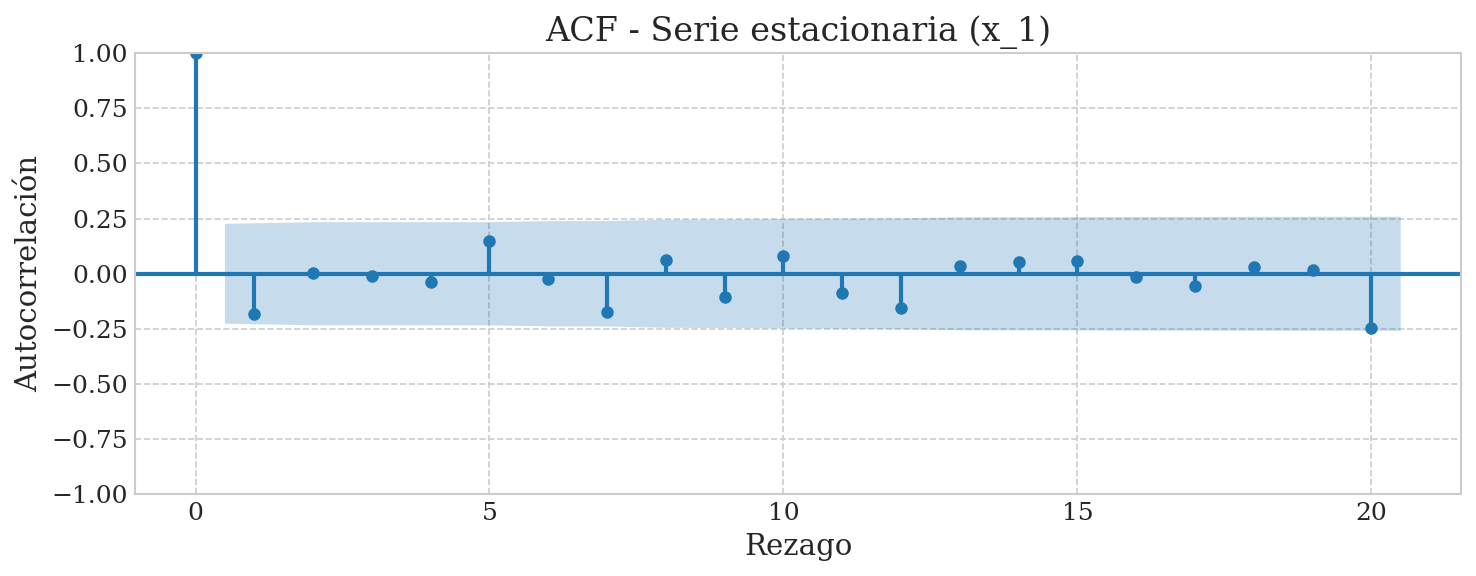

In [13]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf

# --- Parámetros ---
LAGS = 20
# --- Cálculo numérico de la ACF (opcional, por si quieres inspeccionarla) ---
acf_vals = acf(x_1, nlags=LAGS, fft=True)       # acf_vals[0] = 1 en lag 0
conf = 1.96 / np.sqrt(len(x_1))                 # banda de confianza aprox
print("ACF (0..LAGS):", np.round(acf_vals, 3))
print(f"Banda 95% aprox: ±{conf:.3f}")

# --- Gráfico de ACF con bandas de confianza ---
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(x_1, lags=LAGS, ax=ax, alpha=0.05, fft=True)
ax.set_title("ACF - Serie estacionaria (x_1)")
ax.set_xlabel("Rezago")
ax.set_ylabel("Autocorrelación")
plt.tight_layout()
plt.show()

ACF (lags 0..20): [ 1.     0.938  0.858  0.781  0.729  0.691  0.642  0.603  0.575  0.539
  0.49   0.407  0.327  0.264  0.218  0.171  0.133  0.086  0.052  0.023
 -0.003]
Banda 95% aprox: ±0.225 (N=76)


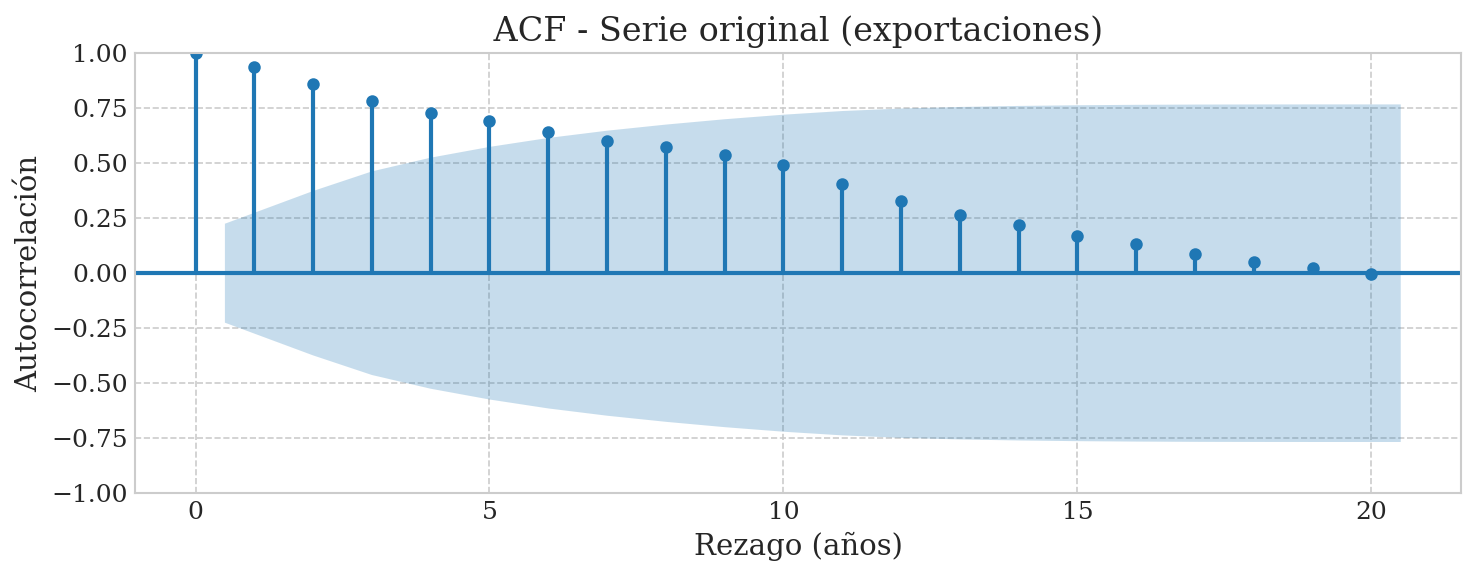

In [14]:
ts = df["exportaciones"].astype(float).dropna()
n = len(ts)

# --- Cálculo numérico (opcional) ---
acf_vals = acf(ts, nlags=LAGS, fft=True)
conf_band = 1.96 / np.sqrt(n)
print("ACF (lags 0..{}):".format(LAGS), np.round(acf_vals, 3))
print(f"Banda 95% aprox: ±{conf_band:.3f} (N={n})")

# --- Gráfico ACF ---
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(ts, lags=LAGS, ax=ax, alpha=0.05, fft=True)   # alpha=0.05 dibuja bandas 95%
ax.set_title("ACF - Serie original (exportaciones)".center(60))
ax.set_xlabel("Rezago (años)")
ax.set_ylabel("Autocorrelación")
plt.tight_layout()
plt.show()